# Goals
Here, we will plot the correlational structure and number of DEGs for single ligand treatment conditions.

# Import

In [1]:
# Repo-relative paths: inputs from imports_stable/, outputs to analysis_outs/
import os
from pathlib import Path
_here = Path.cwd().resolve()
REPO_DIR = str(next(p for p in [_here, *_here.parents] if (p / "imports_stable").is_dir()))
IMPORTS_DIR = f"{REPO_DIR}/imports_stable"
OUTS_DIR = f"{REPO_DIR}/analysis_outs/02_combinatorial_screen_signalseq_SIG13"

import pandas as pd
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False

In [2]:
degSingle = pd.read_csv(f"{IMPORTS_DIR}/SIG13/analysis_outs/glmGamPoi/glmGamPoi_singleTerm_lfc_0.1filter.csv")
coeffSingle = pd.read_csv(f"{IMPORTS_DIR}/SIG13/analysis_outs/glmGamPoi/glmGamPoi_singleTerm_coefficients_0.1filter.csv")

# Plot DEG Numbers

In [3]:
linker_conditions = (degSingle
    .query('adj_pval < 0.1')
    [degSingle['condition'].str.contains('linker')]
    .groupby('condition')
    .size()
    .sort_values(ascending=False)
    .reset_index(name = "n_degs")
)

def rename_linker_condition(condition):
    if condition.startswith('linker_'):
        ligand = condition[len('linker_'):]
        return f"{ligand}_SetB"
    else:
        ligand = condition[:-len('_linker')]
        return f"{ligand}_SetA"

linker_conditions['condition'] = linker_conditions['condition'].apply(rename_linker_condition)

/tmp/ipykernel_2295449/1371849569.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  linker_conditions = (degSingle


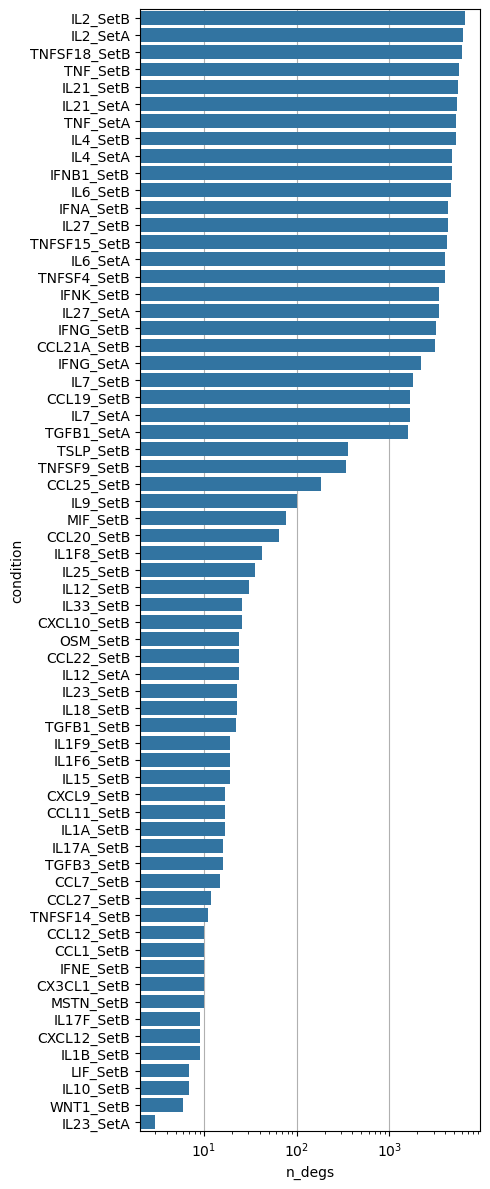

In [4]:
plt.figure(figsize=(5,12))
ax = sns.barplot(
    data=linker_conditions,
    y='condition',
    x='n_degs'
)
ax.set_xscale('log')
ax.grid(True, axis='x')
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()
os.makedirs(f"{OUTS_DIR}/plots", exist_ok=True)
ax.figure.savefig(f"{OUTS_DIR}/plots/linkerOnly_nDEGs_barplot.pdf", bbox_inches="tight")

In [8]:
linker_conditions[['ligand', 'set']] = linker_conditions['condition'].str.split('_', n=1, expand=True)

ligand_avg_degs = (linker_conditions
    .groupby('ligand')['n_degs']
    .mean()
    .sort_values(ascending=False)
    .reset_index(name='mean_n_degs')
)

ligand_avg_degs.query('mean_n_degs > 50')

,ligand,mean_n_degs
0,IL2,6318.0
1,TNFSF18,6131.0
2,IL21,5435.5
3,TNF,5428.5
4,IL4,4978.5
5,IFNB1,4696.0
6,IFNA,4326.0
7,IL6,4290.5
8,TNFSF15,4218.0
9,TNFSF4,3962.0
